In [58]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from matplotlib.widgets import RangeSlider
from ipywidgets import interact, IntSlider, SelectionSlider
import requests
import warnings
from adjustText import adjust_text

warnings.simplefilter("ignore", pd.errors.PerformanceWarning)
warnings.filterwarnings("ignore", category=FutureWarning, module="pandas")
with warnings.catch_warnings():
    warnings.filterwarnings("ignore", category=FutureWarning, module="pandas")
warnings.filterwarnings("ignore", category=DeprecationWarning, module="pandas")

from pricing.pricer import PricerClass
from itertools import combinations
from calibration import Calibration
from tradescreener import tradeScreener
from plotting_utils import residuals_actualFitted, multipleResiduals, actualVsFittedCurve, \
    fittingErrorsHeatmap, threeFactorPlot, twoFactorPlot, factorsForwardsPlot, fittingErrorsHeatmap_fwd, \
    currentErrorsHeatmap_fwd



In [4]:
def getUnsRate(startDate, endDate, rate):
    url = f'https://markets.newyorkfed.org/api/rates/unsecured/{rate}/search.json?startDate={startDate}&endDate={endDate}&type=rate'
    response = requests.get(url = url)
    response.raise_for_status()
    data = response.json()
    index = [data['refRates'][i]['effectiveDate'] for i in range(len(data['refRates']))]
    ratePath = [data['refRates'][i]['percentRate'] for i in range(len(data['refRates']))]
    return pd.Series(ratePath, index = index)

**Deciphering the labels of the ZCB Dataset**

| Series                      | Compounding Convention      | Mnemonic(s) |
|----------------------------|-----------------------------|-------------|
| Zero-coupon yield          | Continuously Compounded     | SVENXXX     |
| Par yield                  | Coupon-Equivalent           | SVENPYXX    |
| Instantaneous forward rate | Continuously Compounded     | SVENFXX     |
| One-year rates,  1/4/9 years forward      | Coupon-Equivalent           | SVEN1FXX    |
| Parameters                 | N/A                         | BETA0 to TAU2 |

In [5]:
data = pd.read_csv('data/feds200628.csv')

In [6]:
# zeroCouponYields = data[[]]
zeroCouponYields = data[['Date']+[x for x in data.columns if 'SVENY' in x]].dropna().set_index('Date').rename_axis('date')
zeroCouponYields.columns = [int(x.split('SVENY')[1]) for x in zeroCouponYields.columns]

startDate = zeroCouponYields.index.min()
endDate = zeroCouponYields.index.max()
dtParams = dict(startDate = startDate, endDate = endDate)
effr = getUnsRate(**dtParams, rate = 'effr').sort_index()

zeroCouponYields['short'] = effr
zeroCouponYields = zeroCouponYields[['short'] + [x for x in zeroCouponYields.columns if 'short' not in str(x)]]
zeroCouponYields = zeroCouponYields.dropna()
zeroCouponYields

,short,1,2,3,4,5,6,7,8,9,...,21,22,23,24,25,26,27,28,29,30
date,,,,,,,,,,,,,,,,,,,,,
2000-07-03,7.03,6.379015,6.273423,6.168424,6.120122,6.105547,6.106725,6.114109,6.122962,6.130978,...,6.072247,6.059162,6.045630,6.031768,6.017680,6.003455,5.989173,5.974899,5.960690,5.946596
2000-07-05,6.52,6.364429,6.261347,6.154370,6.103391,6.086932,6.087130,6.094250,6.103363,6.112015,...,6.067115,6.054930,6.042223,6.029113,6.015704,6.002089,5.988348,5.974552,5.960761,5.947026
2000-07-06,6.51,6.402654,6.305459,6.213675,6.174610,6.163515,6.164377,6.169455,6.175137,6.179757,...,6.109480,6.097794,6.085885,6.073841,6.061741,6.049648,6.037619,6.025700,6.013928,6.002336
2000-07-07,6.42,6.343916,6.256713,6.151972,6.099668,6.083238,6.085086,6.094762,6.106720,6.118122,...,6.076730,6.062954,6.048504,6.033523,6.018136,6.002455,5.986579,5.970592,5.954568,5.938572
2000-07-10,6.51,6.348001,6.281728,6.185449,6.130973,6.110459,6.109170,6.116921,6.127804,6.138611,...,6.087336,6.072089,6.056111,6.039557,6.022562,6.005248,5.987720,5.970071,5.952381,5.934722
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-03-16,3.64,3.659700,3.648200,3.672800,3.724900,3.797100,3.883700,3.979600,4.080700,4.183800,...,5.017400,5.038500,5.052600,5.060100,5.061300,5.056700,5.046500,5.031300,5.011400,4.987200
2026-03-17,3.64,3.653800,3.638200,3.659500,3.708900,3.779200,3.864200,3.958900,4.059300,4.161900,...,5.002500,5.025000,5.040400,5.049300,5.052000,5.048800,5.040200,5.026500,5.008100,4.985400
2026-03-18,3.64,3.711800,3.711600,3.741600,3.794800,3.865200,3.947800,4.038400,4.133500,4.230200,...,5.029900,5.052500,5.068600,5.078500,5.082400,5.080700,5.073800,5.062000,5.045700,5.025100


In [7]:
fwdRates = data[['Date']+[x for x in data.columns if 'SVEN1F' in x]].dropna().set_index('Date').rename_axis('date')
fwdRates.columns = ['1y1y', '5y1y', '10y1y']
fwdRates.index = pd.to_datetime(fwdRates.index)
fwdRates

,1y1y,5y1y,10y1y
date,,,
1971-08-16,6.4427,6.4620,6.4620
1971-08-17,6.2114,6.3144,6.3146
1971-08-18,6.0583,6.6915,6.7992
1971-08-19,5.9632,6.6615,6.8015
1971-08-20,6.1075,6.6167,6.6591
...,...,...,...
2026-03-16,3.6700,4.1277,5.2760
2026-03-17,3.6555,4.1012,5.2507
2026-03-18,3.7459,4.1896,5.2592


### 1. Testing different calibrations

In [158]:
sampleDates = ('2014-01-01','2022-01-01')
MATURITIES = [x for x in zeroCouponYields.columns if x != 'short']
termStructurePath = zeroCouponYields.copy()[sampleDates[0]:sampleDates[1]]
cal = Calibration(termStructurePath, maturities = MATURITIES, fairly_priced=[2, 10])
best_alpha =cal.calibrateAlphaSecondStep(grid = np.arange(0.5, 3, 0.01))
best_sigma = cal.calibrateSigma(alpha_r = best_alpha['alpha_r'], alpha_m = best_alpha['alpha_m'], 
                                    alpha_l = best_alpha['alpha_l'], initialGuess = [0.01092, 0.00964, 0.212])
best_mu = cal.calibrateMu(alpha_r = best_alpha['alpha_r'], alpha_m = best_alpha['alpha_m'], alpha_l = best_alpha['alpha_l'], 
                         sigma_m = best_sigma['sigma_m'], sigma_l = best_sigma['sigma_l'], rho = best_sigma['rho'], initialGuess = 0.01, lossDecayFactor= 0.8)

TypeError: Calibration.__init__() missing 4 required positional arguments: 'forwardTermStructurePath', 'useInputForwards', 'fairly_priced_fwd', and 'fwd_deltaTau'

What happens with different calibration sets?

In [ ]:
calibrationSets = [
    ('2000-07-03','2008-07-01'),
    ('2007-07-01','2015-07-01'),
    ('2014-01-01','2022-01-01')]

calibrationResults = []

for sampleDates in calibrationSets:
    print(f'Calibrating on {sampleDates[0]} - {sampleDates[1]}')
    termStructurePath = zeroCouponYields.copy()[sampleDates[0]:sampleDates[1]]
    cal = Calibration(termStructurePath, maturities = MATURITIES, fairly_priced=[2, 10])
    best_alpha =cal.calibrateAlphaSecondStep(grid = np.arange(0.5, 3, 0.01))
    best_sigma = cal.calibrateSigma(alpha_r = best_alpha['alpha_r'], alpha_m = best_alpha['alpha_m'], 
                                        alpha_l = best_alpha['alpha_l'], initialGuess = [0.01092, 0.00964, 0.212])
    best_mu = cal.calibrateMu(alpha_r = best_alpha['alpha_r'], alpha_m = best_alpha['alpha_m'], alpha_l = best_alpha['alpha_l'], 
                            sigma_m = best_sigma['sigma_m'], sigma_l = best_sigma['sigma_l'], rho = best_sigma['rho'], initialGuess = 0.01, lossDecayFactor= 0.8)
    calibrationResults.append([
        best_alpha['alpha_r'],
        best_alpha['alpha_m'],
        best_alpha['alpha_l'],
        best_alpha['loss'],
        best_sigma['sigma_m'],
        best_sigma['sigma_l'],
        best_sigma['rho'],
        best_sigma['loss'],
        best_mu['mu'],
        best_mu['loss'],
    ])

Calibrating on 2000-07-03 - 2008-07-01
alpha_r: 2.990000000000002, alpha_m: 0.37360248386652345,               alpha_l: 0.05046278332473138, loss: 0.018013174952302643,              success: True, message: CONVERGENCE: NORM_OF_PROJECTED_GRADIENT_<=_PGTOL
sigma_m: 0.1013669969258369, sigma_l: 0.0814981734158864, rho: 0.21302652160366206, loss: 1.1154093872750092e-06, success: True, message: CONVERGENCE: NORM_OF_PROJECTED_GRADIENT_<=_PGTOL
mu: 6.32288485357737, loss: 587.0310092195494, success: True, message: CONVERGENCE: REL_REDUCTION_OF_F_<=_FACTR*EPSMCH
Calibrating on 2007-07-01 - 2015-07-01
alpha_r: 2.3000000000000016, alpha_m: 0.4247771895681546,               alpha_l: 0.05338218669536244, loss: 0.056986777302617496,              success: True, message: CONVERGENCE: REL_REDUCTION_OF_F_<=_FACTR*EPSMCH
sigma_m: 0.11302354940878503, sigma_l: 0.12039540804344427, rho: -0.2617049046909402, loss: 4.917660097692848e-06, success: True, message: CONVERGENCE: NORM_OF_PROJECTED_GRADIENT_<=_PGT

In [ ]:
summaryCalibration = pd.DataFrame(calibrationResults, columns = ['alpha_r', 'alpha_m', 'alpha_l', 'alpha_loss', 'sigma_m', 'sigma_l', 'rho', 'sigma_loss', 'mu', 'mu_loss'])
summaryCalibration.insert(loc = 0, column = 'start', value= [x[0] for x in calibrationSets])
summaryCalibration.insert(loc = 1, column = 'end', value= [x[1] for x in calibrationSets])

print(summaryCalibration.T.to_string())

NameError: name 'calibrationResults' is not defined

### 2. Calibrating and Reading extracted factors

In [8]:
sampleDates = ('2014-01-01', '2022-01-01')
print('Calibrating between', sampleDates[0], 'and', sampleDates[1])
termStructurePath = zeroCouponYields.copy()[sampleDates[0]:]
termStructurePath.index = pd.to_datetime(termStructurePath.index)
MATURITIES = [x for x in termStructurePath.columns if x != 'short']

cal = Calibration(termStructurePath=termStructurePath, 
                  forwardTermStructurePath=None,
                  useInputForwards=False,
                  fairly_priced_fwd=[2, 10],
                  fwd_deltaTau= 1,
                  maturities = MATURITIES, fairly_priced=[2, 10])

best_alpha =cal.calibrateAlphaSecondStep(grid = np.arange(0.5, 3, 0.01))

best_sigma = cal.calibrateSigma(alpha_r = best_alpha['alpha_r'], 
                                alpha_m = best_alpha['alpha_m'], 
                                alpha_l = best_alpha['alpha_l'], 
                                initialGuess = [0.01092, 0.00964, 0.212])

best_mu = cal.calibrateMu(alpha_r = best_alpha['alpha_r'], 
                          alpha_m = best_alpha['alpha_m'], 
                          alpha_l = best_alpha['alpha_l'], 
                          sigma_m = best_sigma['sigma_m'], 
                          sigma_l = best_sigma['sigma_l'], 
                          rho = best_sigma['rho'], 
                          initialGuess = 0.01, lossDecayFactor= 0.8, extraction = 'fwd')        # REMARK: Calibration here was done with 2y-fwd and 10y-fwd 1-year

Calibrating between 2014-01-01 and 2022-01-01
alpha_r: 1.2900000000000007, alpha_m: 0.5355626061522365,               alpha_l: 0.02585287035570249, loss: 0.09648815798462351,              success: True, message: CONVERGENCE: NORM_OF_PROJECTED_GRADIENT_<=_PGTOL
sigma_m: 0.10370752452109198, sigma_l: 0.07025377661975803, rho: 0.21453262398068534, loss: 6.622014753379458e-07, success: True, message: CONVERGENCE: NORM_OF_PROJECTED_GRADIENT_<=_PGTOL
mu: 7.446544457241939, loss: 600.9142683552385, success: True, message: CONVERGENCE: REL_REDUCTION_OF_F_<=_FACTR*EPSMCH


Extract the latent factors based on calibrated parameters + print tha latest values of $(r_t, m_t, l_t)$

In [9]:
lf_full = cal.extractLatentFactors_fwd(alpha_r = best_alpha['alpha_r'], alpha_m = best_alpha['alpha_m'], alpha_l = best_alpha['alpha_l'], 
                         sigma_m = best_sigma['sigma_m'], sigma_l = best_sigma['sigma_l'], rho = best_sigma['rho'], mu = best_mu['mu'])

estFactorsDf_full = pd.DataFrame(lf_full, columns = ['medium', 'long'], index = termStructurePath.index)
estFactorsDf_full['short'] = termStructurePath['short']
estFactorsDf_full = estFactorsDf_full[['short', 'medium', 'long']]
for col in ['1y1y', '10y1y']:
    estFactorsDf_full[col] = fwdRates[col]
estFactorsDf_full.iloc[-1]

short     3.640000
medium    1.934447
long      5.263068
1y1y      3.899400
10y1y     5.394000
Name: 2026-03-20 00:00:00, dtype: float64

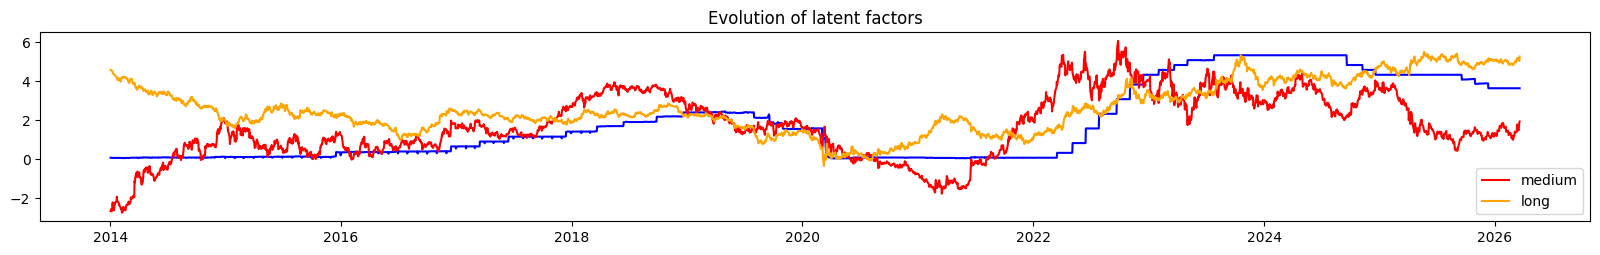

In [10]:
threeFactorPlot(estFactorsDf_full=estFactorsDf_full)

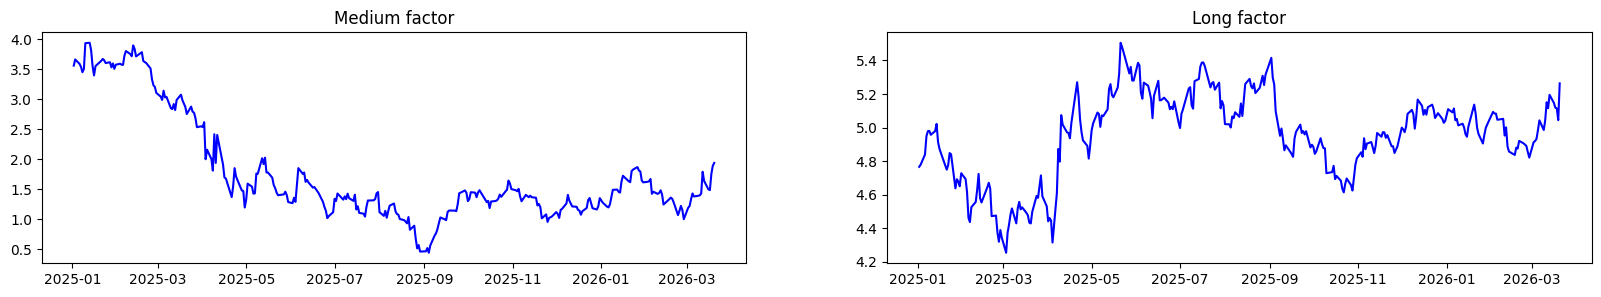

In [11]:
limits = ('2025-01-01', '2026-03-20')
twoFactorPlot(estFactorsDf_full=estFactorsDf_full, limits = limits)

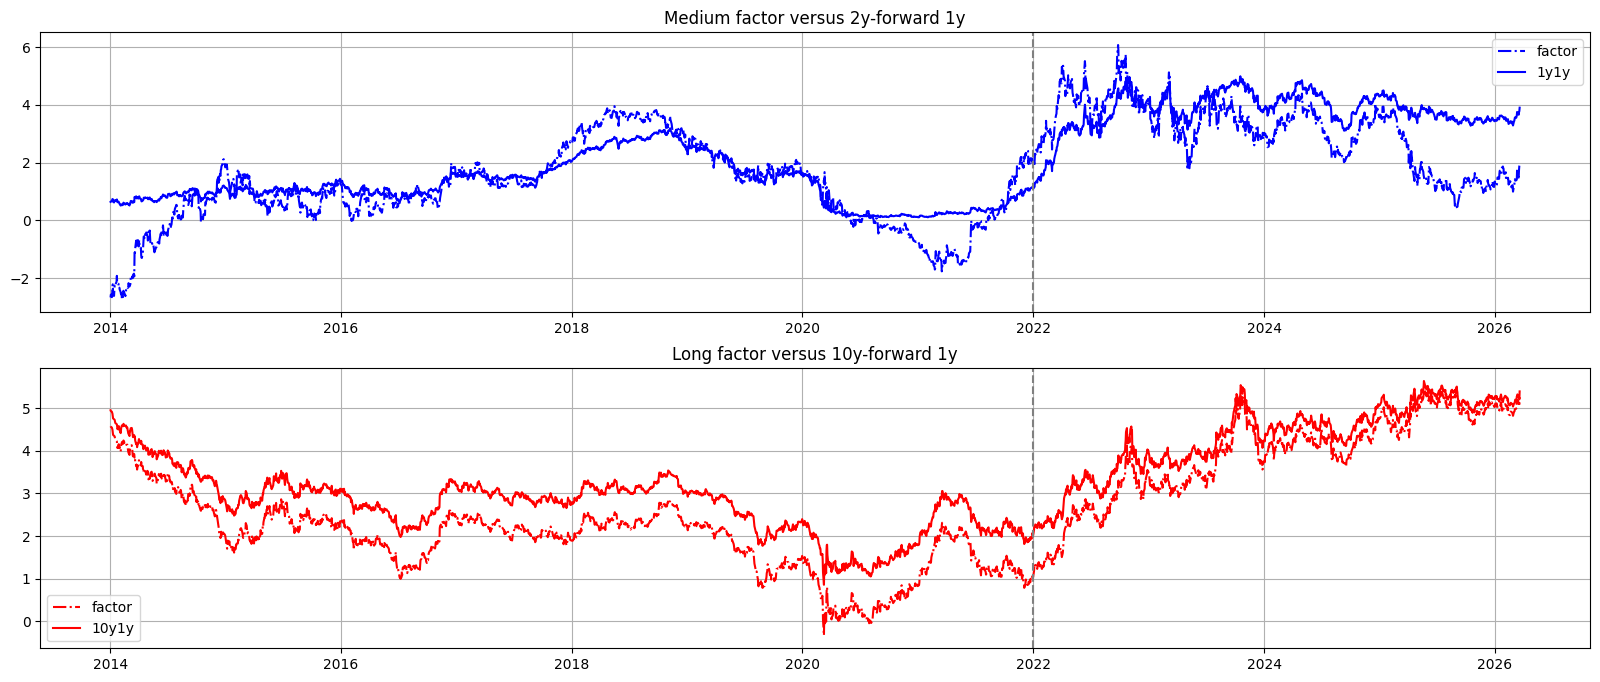

In [12]:
factorsForwardsPlot(estFactorsDf_full=estFactorsDf_full, sampleDates=sampleDates, figsize=(20,8))

### 3. Looking at mispricings

Get the fitted term structure for every day in the sample period based on the calibrated parameters

In [13]:
calParams = dict(alpha_r = best_alpha['alpha_r'], alpha_m = best_alpha['alpha_m'], alpha_l = best_alpha['alpha_l'],
                  sigma_m = best_sigma['sigma_m'], sigma_l = best_sigma['sigma_l'], rho = best_sigma['rho'], mu = best_mu['mu'])

fittedPricer = PricerClass(**calParams)
fittedTs_full = [fittedPricer.termStructure(maturities = MATURITIES, factors = np.array(estFactorsDf_full.iloc[i].values)) for i in range(len(lf_full))]
fittedTs_full_df = pd.DataFrame(fittedTs_full, columns = MATURITIES, index = pd.to_datetime(termStructurePath.index))
fittedTs_full_df.index = pd.to_datetime(fittedTs_full_df.index)

Also let's do the $\Delta \tau$-year forward term structure for $\Delta \tau = {1, 2, ..., 10}$. 

In [14]:
fittedForwardTs_full = {
    deltaTau: [fittedPricer.forwardTermStructure(
        deltaTau = deltaTau, 
        maturities = MATURITIES, 
        factors = np.array(estFactorsDf_full.iloc[i].values)
        ) for i in range(len(lf_full))]
        for deltaTau in range(1, 16)}

for i in fittedForwardTs_full.keys():
    fittedForwardTs_full[i] = pd.DataFrame(fittedForwardTs_full[i], columns = MATURITIES, index = pd.to_datetime(termStructurePath.index))

In [34]:
forwardTermStructurePath = {
    deltaTau: pd.DataFrame({
        x: cal.observedForwardRateSeries(deltaTau = deltaTau, tau = x) for x in range(1, max(MATURITIES) - deltaTau + 1)
        }, index = pd.to_datetime(termStructurePath.index)) for deltaTau in range(1, 16)
}


Interpretation:

- ```fittedForwardTs_full[10] ``` contains a dataframe with the <span style="color:yellow"> model </span> time series of all tenors, 10 years forward
- ```fittedForwardTs_full[10][2] ``` contains the time series of the <span style="color:yellow"> model </span> 10-year forward 2-year rate
- ```forwardTermStructurePath[10]``` contains a dataframe with the  <span style="color:yellow"> observed </span> time series of all tenors, 10 years forward
- ```forwardTermStructurePath[10][2]``` contains the time series of the  <span style="color:yellow"> observed </span> 10-year forward 2-year rate

Robustness check: if the model was fit assuming the 2y1y and 10y1y are priced exactly, the below plot MUST show deviations in the order of zero.

In [37]:
twoYearOneYear_act = forwardTermStructurePath[1][2]
twoYearOneYear_model = fittedForwardTs_full[1][2]

tenYearOneYear_act = forwardTermStructurePath[1][10]
tenYearOneYear_model = fittedForwardTs_full[1][10]

print('Average difference on 2y1y: \t', format((twoYearOneYear_act - twoYearOneYear_model).mean(), '.8f'))
print('Average difference on 10y1y: \t', format((tenYearOneYear_act - tenYearOneYear_model).mean(), '.8f'))

Average difference on 2y1y: 	 0.00000000
Average difference on 10y1y: 	 -0.00000000


Fitting errors in bps on spot yields

In [38]:
fittingErrors = (fittedTs_full_df - termStructurePath).dropna(axis= 1)
fittingErrors_byYear = (fittingErrors.groupby(fittingErrors.index.year).apply(lambda x: np.sqrt((x**2).mean()).round(5))).T * 100

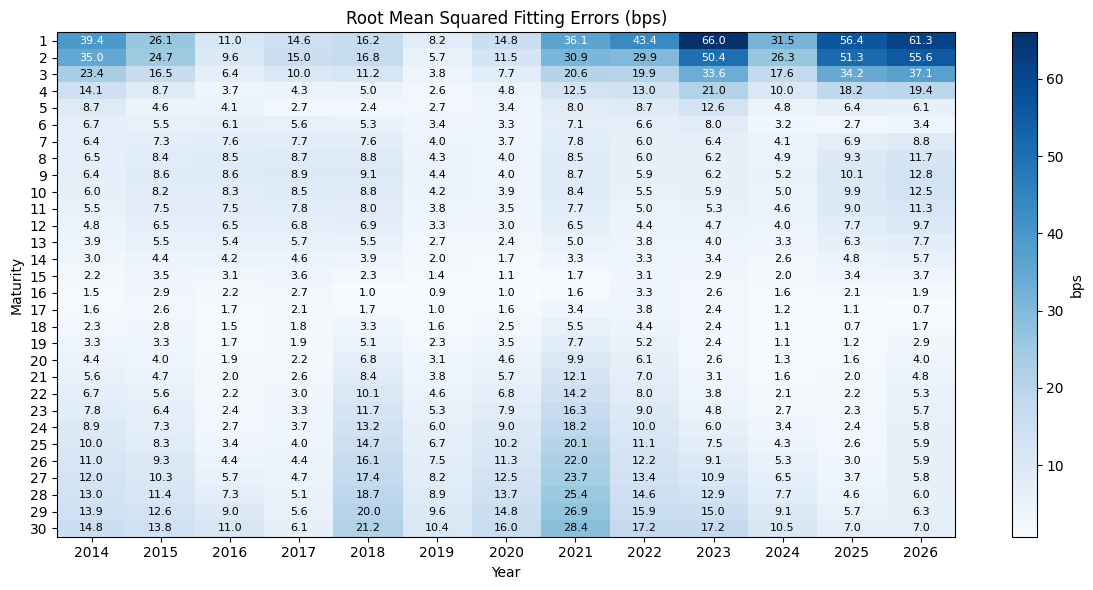

In [18]:
fittingErrorsHeatmap(fittingErrors_byYear=fittingErrors_byYear)

In [39]:
fittingErrors_fwd = {x: fittedForwardTs_full[x] - forwardTermStructurePath[x] for x in fittedForwardTs_full.keys()}

In [67]:
rmse_by_x = {}

for x, df in fittingErrors_fwd.items():
    yearly = df.copy()
    yearly['year'] = pd.to_datetime(yearly.index).year
    rmse_by_x[x] = yearly.groupby('year').apply(lambda g: 100 * np.sqrt((g.drop(columns='year')**2).mean()))

vmin = min(tbl.min().min() for tbl in rmse_by_x.values())
vmax = max(tbl.max().max() for tbl in rmse_by_x.values())

/var/folders/6s/ljt_tdhn2332n40p605w9dgr0000gn/T/ipykernel_2650/1171836122.py:6: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  rmse_by_x[x] = yearly.groupby('year').apply(lambda g: 100 * np.sqrt((g.drop(columns='year')**2).mean()))
/var/folders/6s/ljt_tdhn2332n40p605w9dgr0000gn/T/ipykernel_2650/1171836122.py:6: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  rmse_by_x[x] = yearly.groupby('year').apply(lambda 

/Users/riccardo/Desktop/Personal Projects/Latest/Yield curve models/gauss+/plotting_utils.py:192: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.


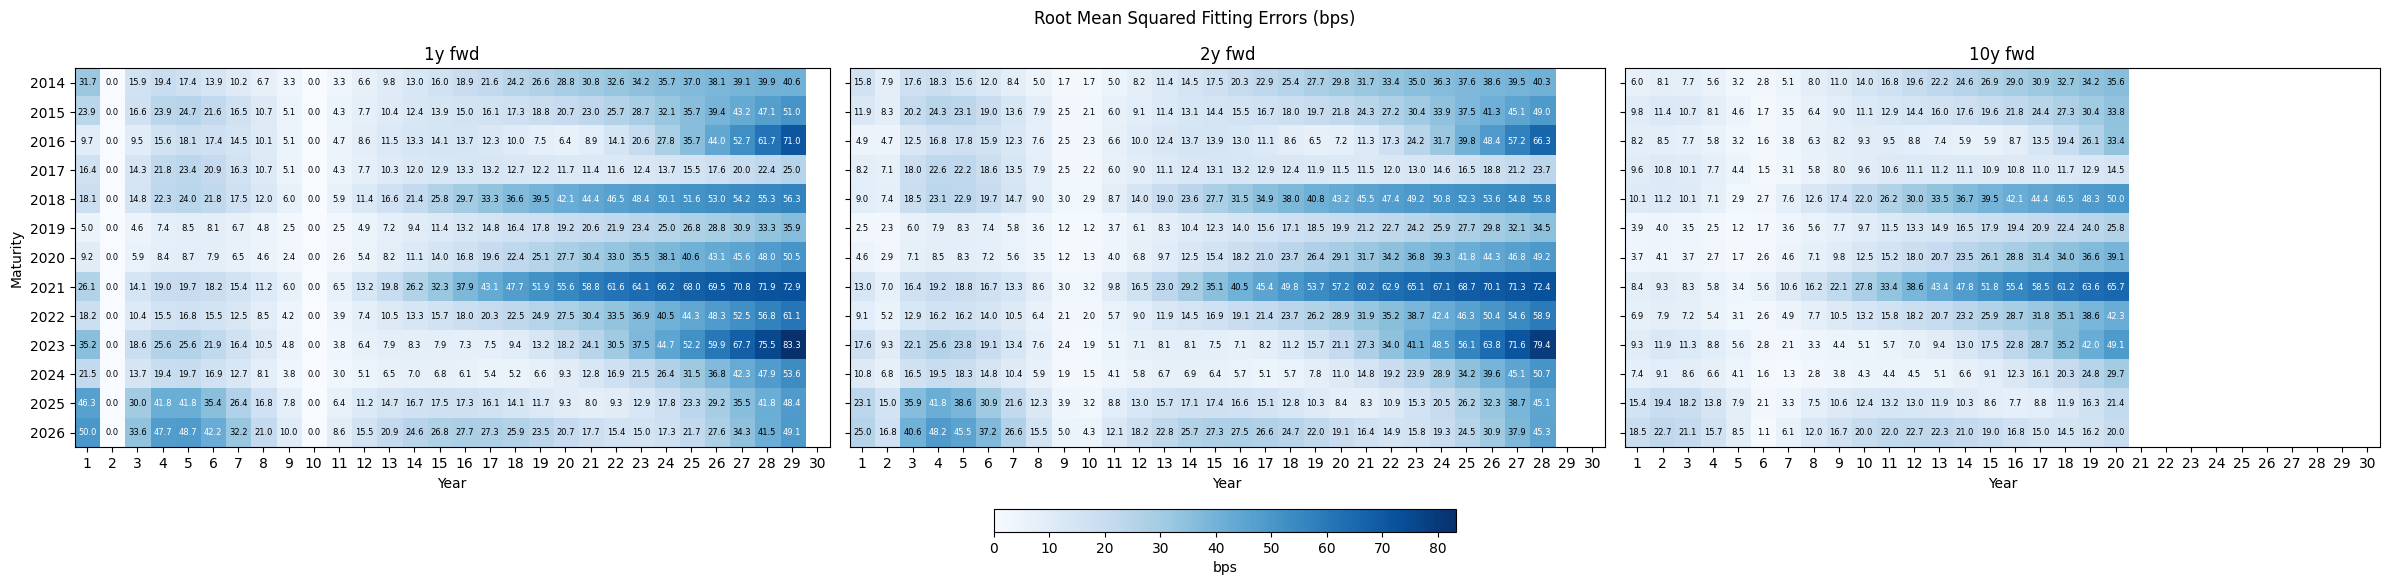

In [66]:
fittingErrorsHeatmap_fwd(rmse_by_x=rmse_by_x, x_list = [1, 2, 10], figsize = (24, 6))

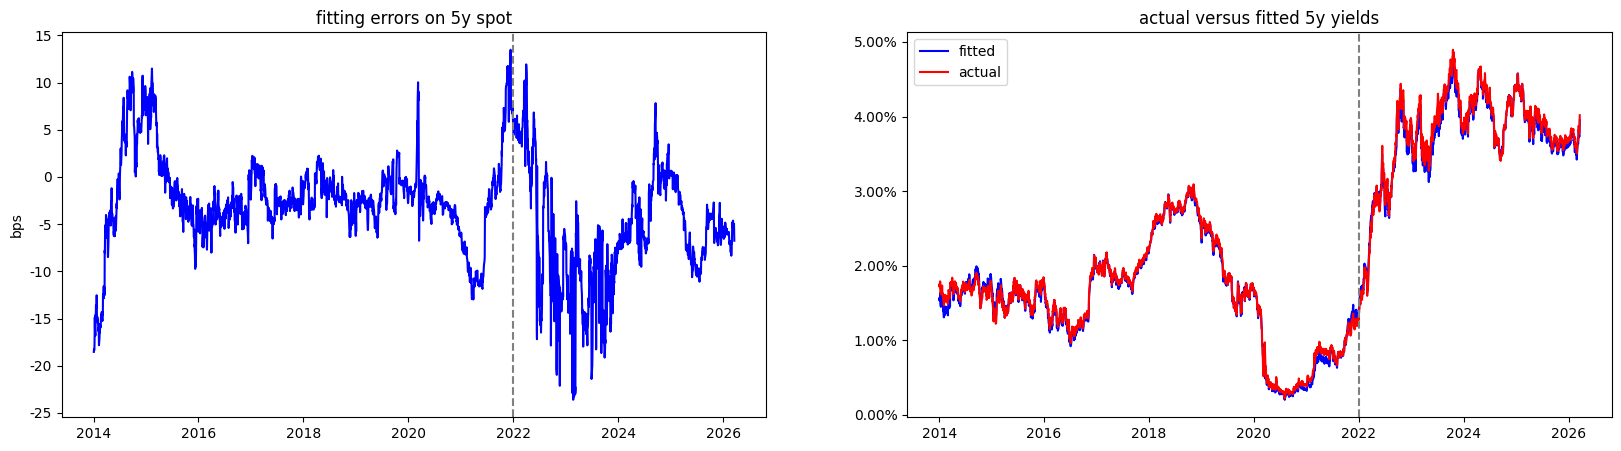

In [ ]:
residuals_actualFitted(fittingErrors=fittingErrors,
                       fittedTs=fittedTs_full_df,
                       termStructurePath=termStructurePath,
                       tenor = 5,
                       sampleDates = sampleDates)

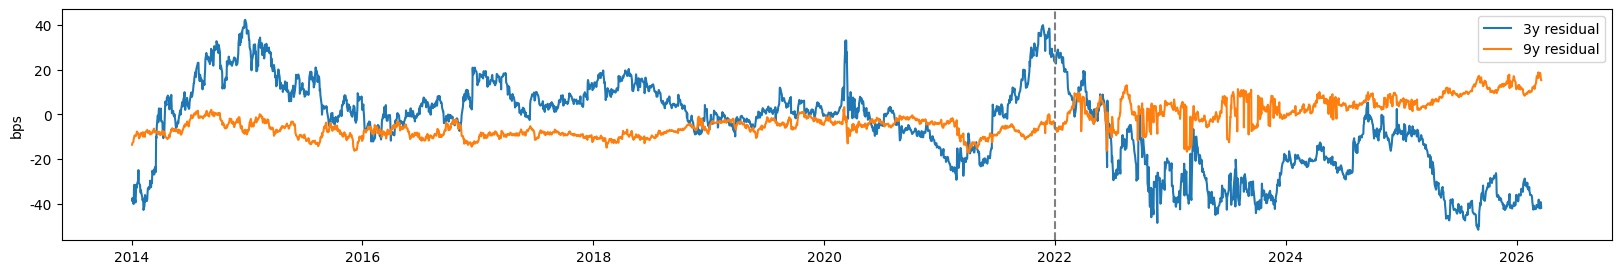

In [ ]:
multipleResiduals(fittingErrors=fittingErrors, sampleDates = sampleDates, tenors = [3,9], figsize = (20,3))

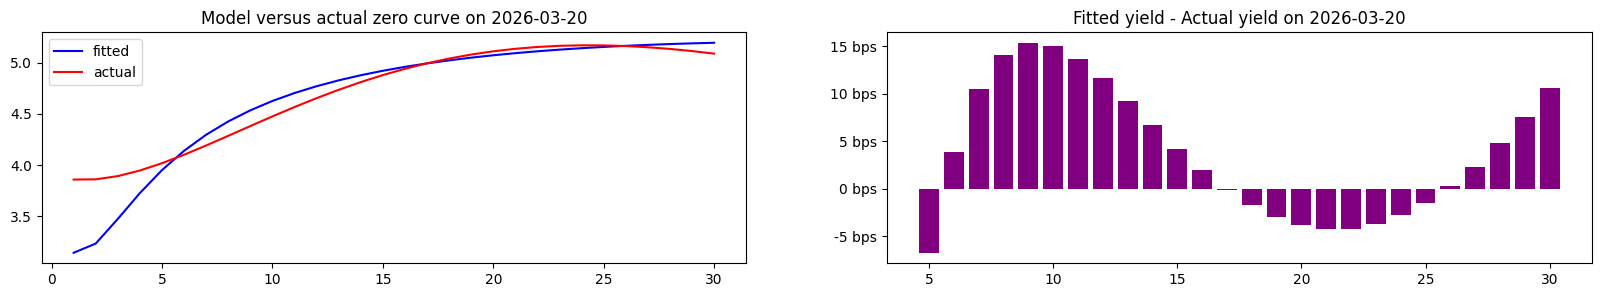

In [ ]:
actualVsFittedCurve(targetDate='2026-03-20',
                    fittedTs_full_df=fittedTs_full_df,
                    termStructurePath=termStructurePath,
                    tenorsAbove=4)

In [22]:
errorData = pd.DataFrame({x: 
              100 *(fittedForwardTs_full[x].iloc[-1] - forwardTermStructurePath[x].iloc[-1]) 
              for x in fittedForwardTs_full.keys()}).round(6)

In [24]:
forwardTermStructurePath[x]

,1,2,3,4,5,6,7,8,9,10,...,21,22,23,24,25,26,27,28,29,30
date,,,,,,,,,,,,,,,,,,,,,
2014-01-02,4.025033,4.293547,4.49166,4.620347,4.692833,4.72470,4.729787,4.718540,4.69842,4.674566,...,4.377740,4.350026,4.323086,4.296839,4.271100,4.245746,4.220579,4.195693,4.171152,4.1466
2014-01-03,4.027427,4.296587,4.49400,4.621820,4.694200,4.72708,4.733680,4.723846,4.70486,4.681167,...,4.364480,4.336647,4.310087,4.284460,4.259767,4.235753,4.212240,4.189527,4.167141,4.1451
2014-01-06,3.997607,4.264067,4.46192,4.591967,4.666667,4.70100,4.708020,4.698293,4.67920,4.655700,...,4.353119,4.325353,4.298359,4.272059,4.246433,4.221033,4.196179,4.171633,4.147266,4.1231
2014-01-07,3.978293,4.244180,4.44204,4.572787,4.648733,4.68458,4.692947,4.683773,4.66440,4.639800,...,4.316339,4.288613,4.262173,4.236679,4.212133,4.188280,4.164939,4.142226,4.119839,4.0978
2014-01-08,4.005393,4.266580,4.45624,4.578560,4.647833,4.67898,4.684687,4.673740,4.65304,4.626633,...,4.279099,4.252586,4.228073,4.204959,4.183433,4.163279,4.144359,4.126452,4.109646,4.0936
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-03-16,4.872713,5.018060,5.15600,5.280240,5.386167,5.47088,5.532653,5.570947,5.58588,5.577967,...,4.944920,4.911960,4.886920,4.870560,4.863700,4.866733,4.880460,4.904880,4.940413,4.9872
2026-03-17,4.851773,4.997633,5.13682,5.262720,5.370667,5.45782,5.522513,5.563653,5.58174,5.577267,...,4.961460,4.927320,4.901067,4.883160,4.874400,4.875507,4.886760,4.908680,4.941513,4.9854
2026-03-18,4.884387,5.023660,5.15604,5.275787,5.378800,5.46274,5.525747,5.567320,5.58748,5.586400,...,5.018380,4.984913,4.958400,4.939660,4.929600,4.928727,4.937440,4.956220,4.985273,5.0251


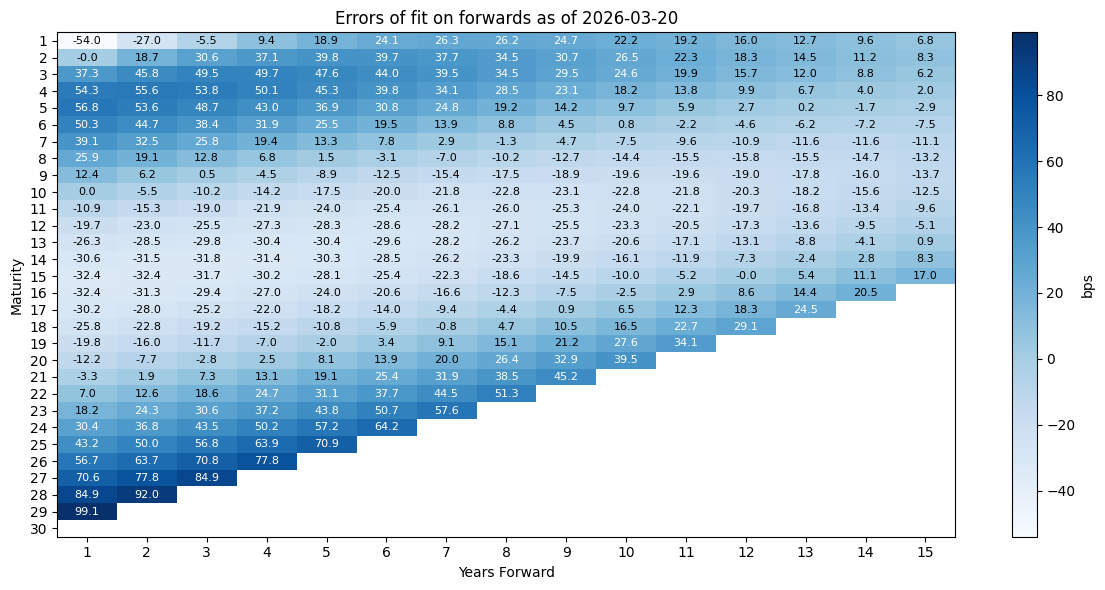

In [65]:
currentErrorsHeatmap_fwd(fittedForwardTs_full = fittedForwardTs_full,
                         forwardTermStructurePath = forwardTermStructurePath)

### 4. Screening attractive trades with the latest data

In [68]:
screen = tradeScreener(modelData = fittedTs_full_df,
                       actualData = zeroCouponYields,
                       maturitySet = [x for x in cal.maturities if int(x) > 4],
                       modelData_fwd=fittedForwardTs_full,
                       actualData_fwd= forwardTermStructurePath,
                       maturitySet_fwd=None)

In [69]:
screen.actualData

,short,1,2,3,4,5,6,7,8,9,...,21,22,23,24,25,26,27,28,29,30
date,,,,,,,,,,,,,,,,,,,,,
2000-07-03,7.03,6.379015,6.273423,6.168424,6.120122,6.105547,6.106725,6.114109,6.122962,6.130978,...,6.072247,6.059162,6.045630,6.031768,6.017680,6.003455,5.989173,5.974899,5.960690,5.946596
2000-07-05,6.52,6.364429,6.261347,6.154370,6.103391,6.086932,6.087130,6.094250,6.103363,6.112015,...,6.067115,6.054930,6.042223,6.029113,6.015704,6.002089,5.988348,5.974552,5.960761,5.947026
2000-07-06,6.51,6.402654,6.305459,6.213675,6.174610,6.163515,6.164377,6.169455,6.175137,6.179757,...,6.109480,6.097794,6.085885,6.073841,6.061741,6.049648,6.037619,6.025700,6.013928,6.002336
2000-07-07,6.42,6.343916,6.256713,6.151972,6.099668,6.083238,6.085086,6.094762,6.106720,6.118122,...,6.076730,6.062954,6.048504,6.033523,6.018136,6.002455,5.986579,5.970592,5.954568,5.938572
2000-07-10,6.51,6.348001,6.281728,6.185449,6.130973,6.110459,6.109170,6.116921,6.127804,6.138611,...,6.087336,6.072089,6.056111,6.039557,6.022562,6.005248,5.987720,5.970071,5.952381,5.934722
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-03-16,3.64,3.659700,3.648200,3.672800,3.724900,3.797100,3.883700,3.979600,4.080700,4.183800,...,5.017400,5.038500,5.052600,5.060100,5.061300,5.056700,5.046500,5.031300,5.011400,4.987200
2026-03-17,3.64,3.653800,3.638200,3.659500,3.708900,3.779200,3.864200,3.958900,4.059300,4.161900,...,5.002500,5.025000,5.040400,5.049300,5.052000,5.048800,5.040200,5.026500,5.008100,4.985400
2026-03-18,3.64,3.711800,3.711600,3.741600,3.794800,3.865200,3.947800,4.038400,4.133500,4.230200,...,5.029900,5.052500,5.068600,5.078500,5.082400,5.080700,5.073800,5.062000,5.045700,5.025100


Remark:
$$ \text{Mispricing} = \text{Actual} - \text{Model} $$
$$ \text{Reversion} = \text{5d Rolling MA of Mispricing} - \text{40d Rolling MA of Mispricing} $$

So:
$$ \text{Mispricing} < 0 \quad \text{  and  } \quad \text{Reversion} > 0 \Longrightarrow \text{Long}$$
$$ \text{Mispricing} > 0 \quad \text{  and  } \quad \text{Reversion} < 0 \Longrightarrow \text{Short}$$

In [70]:
outrightScreen = screen.outrightScreener()
slopeScreen = screen.slopeScreener()
flyScreen = screen.flyScreener()
fwdScreen = screen.outrightScreener_fwd()

slopeDict = screen.buildSlopes()
flyDict = screen.buildFlies()


Text(0.5, 1.0, 'Outright trade screener')

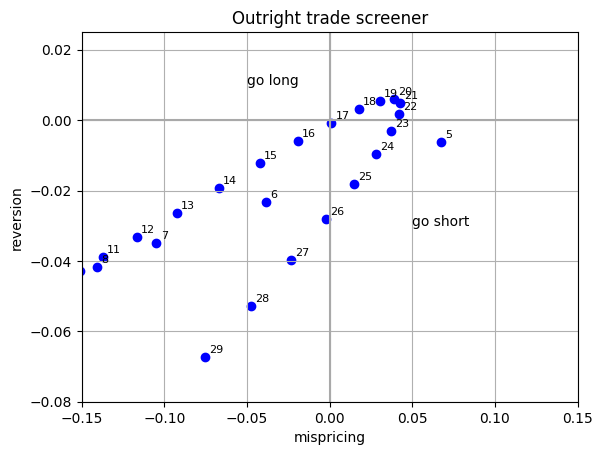

In [71]:
plt.axhline(y = 0, color = 'darkgrey')
plt.axvline(x = 0, color = 'darkgrey')
plt.scatter(outrightScreen['error'], outrightScreen['signal'], color = 'blue')
for i, txt in enumerate(outrightScreen.index):
    plt.annotate(txt,
                 (outrightScreen['error'].iloc[i], outrightScreen['signal'].iloc[i]),
                 xytext=(3,3),
                 textcoords='offset points',
                 fontsize=8)
plt.annotate(text = 'go short', xy = (0.05, - 0.03))
plt.annotate(text = 'go long', xy = (-0.05, + 0.01))
plt.xlim(-0.15, 0.15)
plt.ylim(-0.08, +0.025)
plt.xlabel('mispricing')
plt.ylabel('reversion')
plt.grid(True)
plt.title('Outright trade screener')

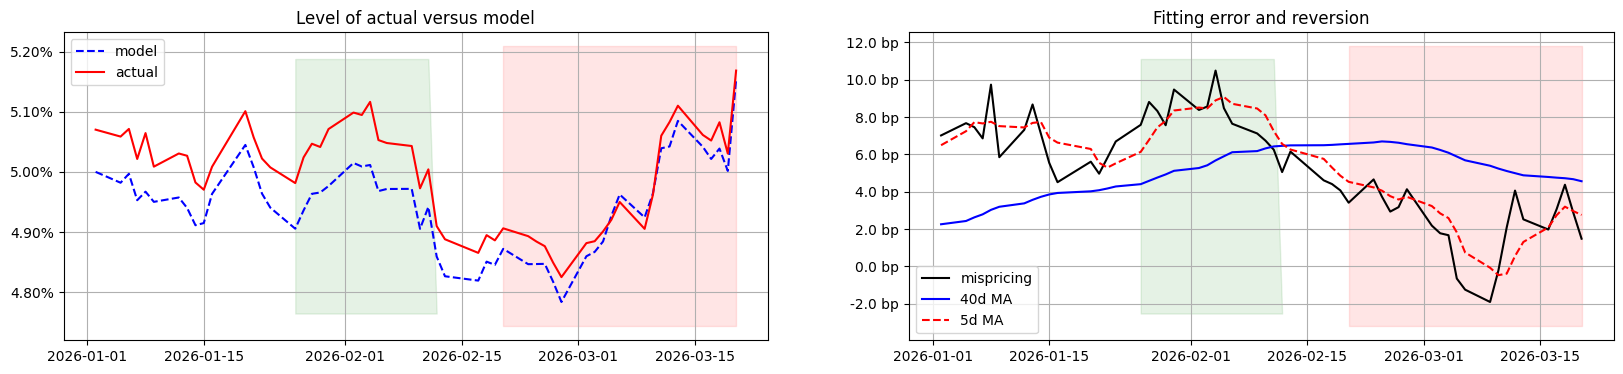

In [72]:
targetTenor = 25
screen.plotModelVsActual(modelSeries=screen.modelData[targetTenor],
                         actualSeries = screen.actualData[targetTenor],
                         shortW = 5, longW = 40, standardW = 14, leftPlotBp = False,
                         startDt = '2022-01-01', endDt = None,
                         display_startDt= '2026-01-01', display_endDt=None)

In [73]:
pd.concat([slopeScreen.loc[np.sign(slopeScreen['signal']) * np.sign(slopeScreen['error']) == -1].sort_values('error').head(10),
           slopeScreen.loc[np.sign(slopeScreen['signal']) * np.sign(slopeScreen['error']) == -1].sort_values('error').tail(10)])

,model,actual,error,signal
5s16s,1.008611,0.9218,-0.086811,0.000301
5s17s,1.042350,0.9757,-0.066650,0.005531
5s18s,1.072149,1.0222,-0.049949,0.009427
5s19s,1.098509,1.0612,-0.037309,0.011758
5s23s,1.176838,1.1465,-0.030338,0.003267
5s20s,1.121841,1.0929,-0.028941,0.012344
6s14s,0.737936,0.7093,-0.028636,0.003996
5s22s,1.160739,1.1353,-0.025439,0.008137
5s21s,1.142489,1.1175,-0.024989,0.011163
7s12s,0.473960,0.4622,-0.011760,0.001798


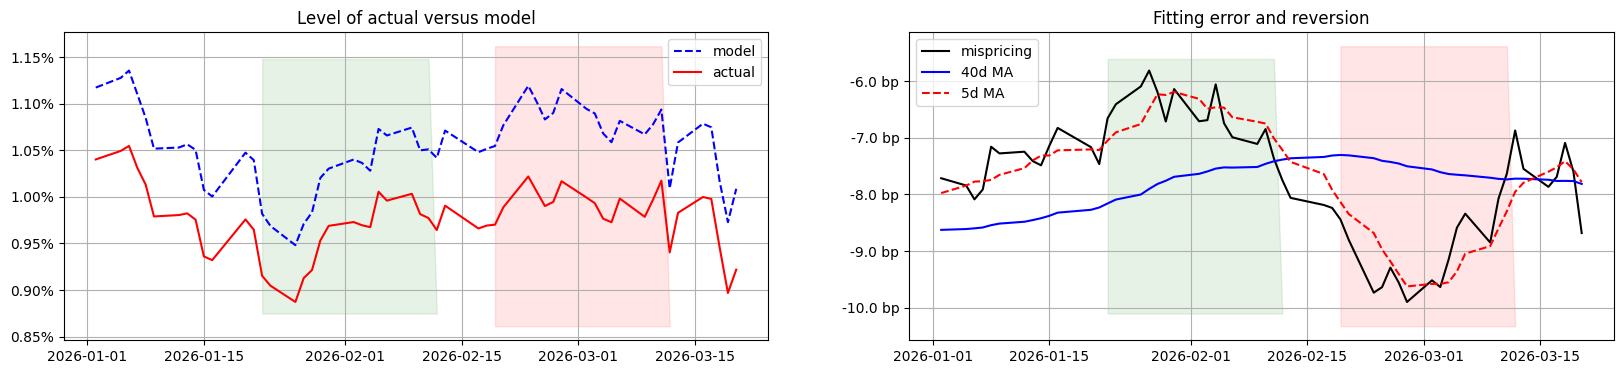

In [74]:
targetSlope = '5s16s'
screen.plotModelVsActual(modelSeries= slopeDict['model'][targetSlope],
                         actualSeries = slopeDict['actual'][targetSlope],
                         shortW = 5, longW = 40, standardW = 14, leftPlotBp = False,
                         startDt = '2022-01-01', endDt = None,
                         display_startDt= '2026-01-01', display_endDt=None)

In [75]:
flyScreen.loc[np.sign(flyScreen['error']) * np.sign(flyScreen['signal']) == -1]

,model,actual,error,signal
5s16s27s,-0.793721,-0.7110,0.082721,-0.034096
6s15s24s,-0.560874,-0.4869,0.073974,-0.008412
7s15s23s,-0.418351,-0.4016,0.016751,-0.013530
9s14s19s,-0.170931,-0.1603,0.010631,-0.000244
10s14s18s,-0.105936,-0.1050,0.000936,-0.001307


Let's see the series of the 5s16s27s fly.

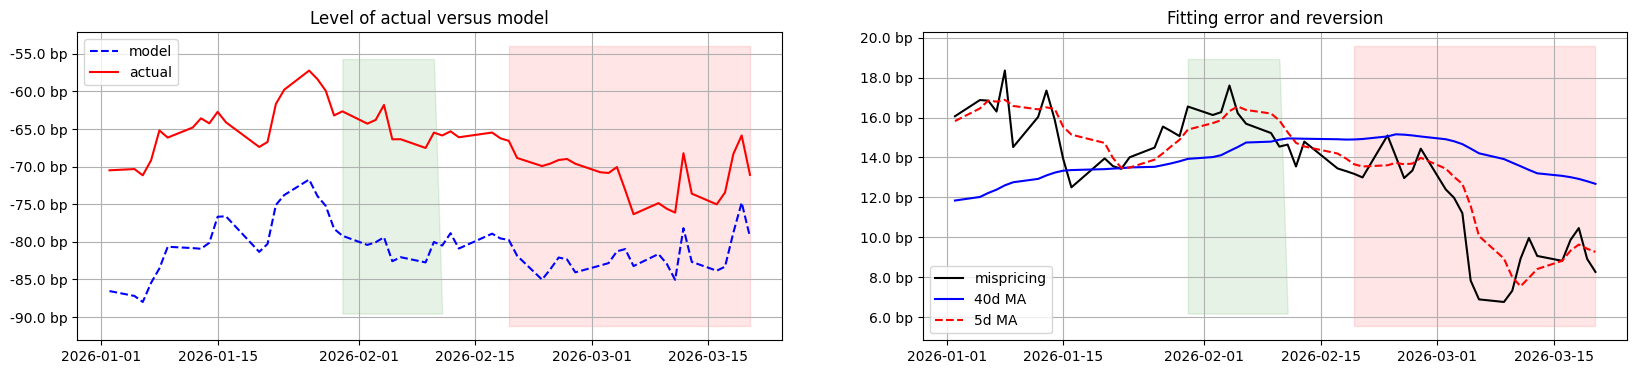

In [76]:
targetFly = '5s16s27s'
screen.plotModelVsActual(modelSeries=flyDict['model'][targetFly],
                         actualSeries = flyDict['actual'][targetFly],
                         shortW = 5, longW = 40, standardW = 14, leftPlotBp=True,
                         startDt = '2022-01-01', endDt = None,
                         display_startDt= '2026-01-01', display_endDt=None)

In [77]:
flyScreen = screen.flyScreener().reset_index(names='fly')
backtestFly = screen.allFliesBacktest(startDt='2022-01-01', endDt=None,
                        shortW = 5, longW = 40, standardW=14)
flyScreen = pd.merge(left = flyScreen,
         right = backtestFly).sort_values(by = 'signal')

In [78]:
flyScreen.loc[flyScreen['fly'] == '5s16s27s']

,fly,model,actual,error,signal,hitrate,skew,avg days,median days,n_trades
10,5s16s27s,-0.793721,-0.711,0.082721,-0.034096,0.6,1.595558,7.9,3.5,40


Text(0.5, 1.0, 'Outright trade screener')

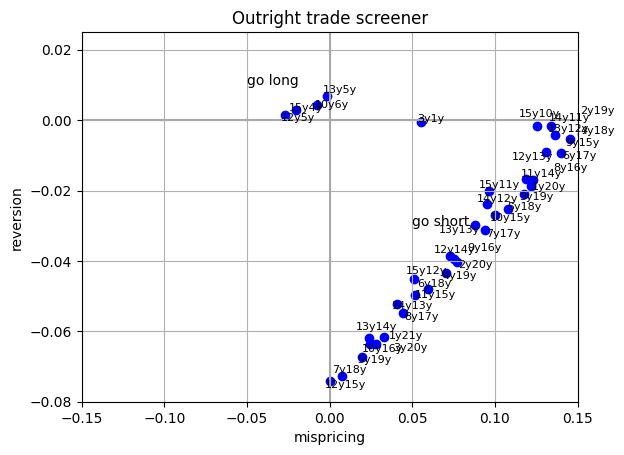

In [80]:
subset = fwdScreen.loc[np.sign(fwdScreen['error']) * np.sign(fwdScreen['signal']) == -1]
plt.axhline(y = 0, color = 'darkgrey')
plt.axvline(x = 0, color = 'darkgrey')
plt.scatter(subset['error'], subset['signal'], color = 'blue')
texts = []
for i, txt in enumerate(subset.index):
    texts.append(
        plt.text(subset['error'].iloc[i],
                 subset['signal'].iloc[i],
                 txt,
                 fontsize=8)
    )
adjust_text(texts)
plt.annotate(text = 'go short', xy = (0.05, - 0.03))
plt.annotate(text = 'go long', xy = (-0.05, + 0.01))
plt.xlim(-0.15, 0.15)
plt.ylim(-0.08, +0.025)
plt.xlabel('mispricing')
plt.ylabel('reversion')
plt.grid(True)
plt.title('Outright trade screener')

In [81]:
subset.sort_values('error')

,model,actual,error,signal
12y5y,5.426754,5.399942,-0.026813,0.001540
15y4y,5.401275,5.380900,-0.020375,0.002965
10y6y,5.450609,5.442900,-0.007709,0.004328
13y5y,5.434606,5.433054,-0.001552,0.006757
12y15y,5.490074,5.490300,0.000226,-0.074237
7y18y,5.490950,5.498471,0.007522,-0.072571
5y19y,5.492528,5.512340,0.019812,-0.067198
13y14y,5.493221,5.516992,0.023771,-0.061961
10y16y,5.493175,5.517740,0.024565,-0.063535
3y20y,5.493575,5.521533,0.027958,-0.063542


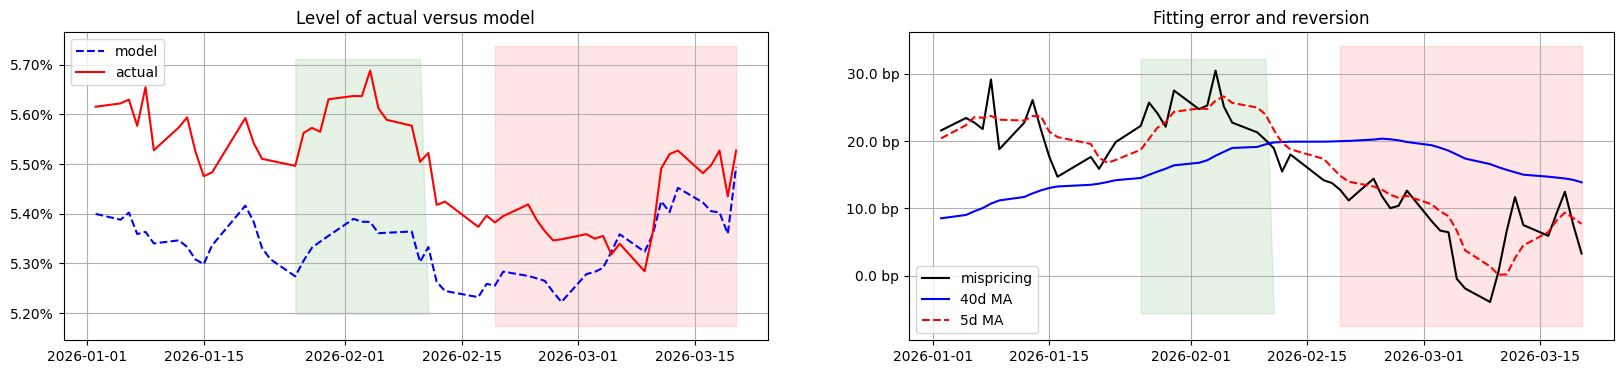

In [736]:
forward = 1
tenor = 21
screen.plotModelVsActual(modelSeries=screen.modelData_fwd[forward][tenor],
                         actualSeries=screen.actualData_fwd[forward][tenor],
                         shortW = 5, longW = 40, standardW = 14, leftPlotBp=False,
                         startDt = '2022-01-01', endDt = None,
                         display_startDt= '2026-01-01', display_endDt=None)

### 3. Forwards and risk premia

With the parameters we calibrated, how likely is our choice of $\tau$ and $\tau'$ likely to distort our estimate of $\lambda_t$?

***Answer: BIG TIME***

In [454]:
curveToday = termStructurePath.iloc[-1, 1:].to_list()

for x,y in zip([x for x in range(13, 20)], [x for x in range(14, 21)]):
    print(f"Tau = {x} and Tau' = {y}:", cal.lambdaFromForwards(tau = x, tauPrime= y, deltaTau= 1, curve = curveToday, **calParams))

Tau = 13 and Tau' = 14: 3.443169718794701
Tau = 14 and Tau' = 15: 1.814598830307812
Tau = 15 and Tau' = 16: -0.20364866598295792
Tau = 16 and Tau' = 17: -4.4134199808935
Tau = 17 and Tau' = 18: -14.795039949194043
Tau = 18 and Tau' = 19: -61.25615529226947
Tau = 19 and Tau' = 20: 89.1728839024969


The code below implements the correct calculation of $\lambda$ as defined in the integral of Eq. A9.27.

In [455]:
curveToday = termStructurePath.iloc[-1, 1:].to_list()

for x,y in zip([x for x in range(8, 20)], [x for x in range(9, 21)]):
    print(f"Tau = {x} and Tau' = {y}:", cal.lambdaFromForwards_corrected(tau = x, tauPrime= y, deltaTau= 1, curve = curveToday, **calParams))

Tau = 8 and Tau' = 9: 2.6074394254849182
Tau = 9 and Tau' = 10: 2.1893928246047856
Tau = 10 and Tau' = 11: 1.7563199711060817
Tau = 11 and Tau' = 12: 1.2385561423999092
Tau = 12 and Tau' = 13: 0.7409634929062797
Tau = 13 and Tau' = 14: 0.19723577199123501
Tau = 14 and Tau' = 15: -0.38653920188101054
Tau = 15 and Tau' = 16: -0.8664767130981954
Tau = 16 and Tau' = 17: -1.4048325238916595
Tau = 17 and Tau' = 18: -1.9759231922388896
Tau = 18 and Tau' = 19: -2.4513131579614043
Tau = 19 and Tau' = 20: -2.9294509446918755


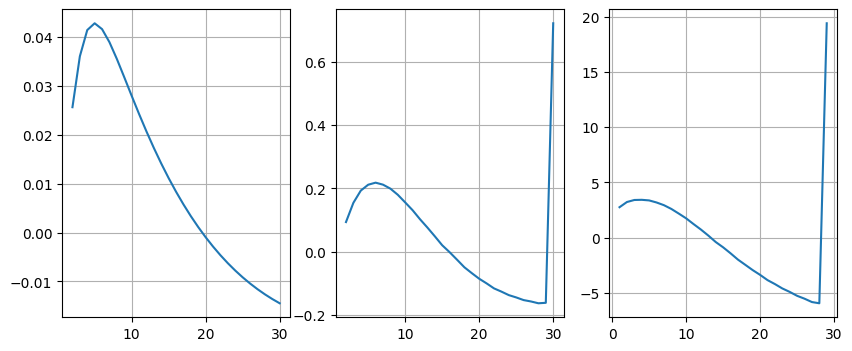

In [456]:
fig, ax = plt.subplots(nrows =1 ,ncols =3, figsize = (10,4))

amtOfRisk_drift = np.array([fittedPricer.amountOfRisk_drift(tau = x, deltaTau= 1, n_steps=1000) for x in termStructurePath.columns if type(x) == int])
amtOfRisk_conv = np.array([fittedPricer.amountOfRisk_convexity(tau = x, deltaTau= 1, n_steps=1000) for x in termStructurePath.columns if type(x) == int])
amtOfRisk_tot = amtOfRisk_drift + amtOfRisk_conv
forwardCurveToday = [cal.observedForwardRate(tau=x, deltaTau=1, curve = curveToday) for x in xaxis]

taus = xaxis[:-1]
differentLambdas = np.array([
    cal.lambdaFromForwards_corrected(tau=x, tauPrime=x+1, deltaTau=1, curve=curveToday, **calParams)
    for x in taus
])

ax[0].plot(xaxis[1:], np.diff(amtOfRisk_tot))
ax[1].plot(xaxis[1:], np.diff(forwardCurveToday))
ax[2].plot(taus, differentLambdas)
for i in range(0,3):
    ax[i].grid()

Text(0.5, 0.98, "tau = 12, tau' = 13")

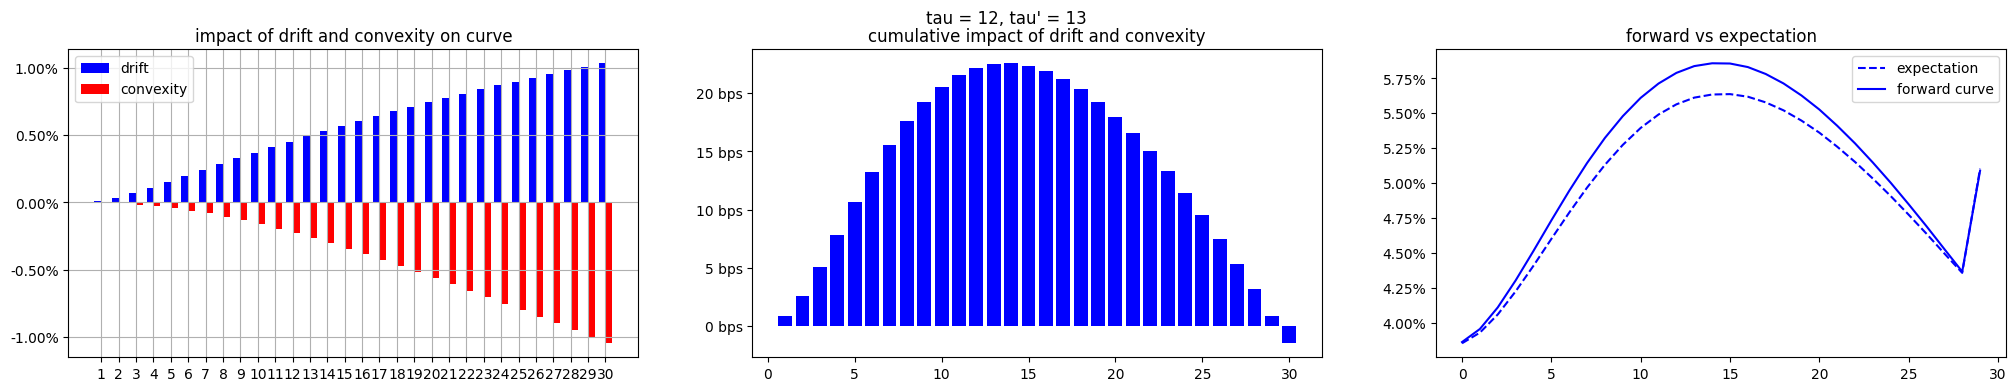

In [461]:
x= 12
y= 13

lambdaToday = cal.lambdaFromForwards_corrected(tau = x, tauPrime= y, deltaTau= 1, curve = curveToday, **calParams)
amtOfRisk_drift = [fittedPricer.amountOfRisk_drift(tau = x, deltaTau= 1, n_steps=1000) for x in termStructurePath.columns if type(x) == int]
amtOfRisk_conv = [fittedPricer.amountOfRisk_convexity(tau = x, deltaTau= 1, n_steps=1000) for x in termStructurePath.columns if type(x) == int]

driftRP = lambdaToday*np.asarray(amtOfRisk_drift)
convRP = np.asarray(amtOfRisk_conv)         # this already embeds the minus sign ahead
totRP = driftRP + convRP                                # makes sense to sum it to driftRP like that

forwardCurve = [cal.observedForwardRate(curve = curveToday, tau = x, deltaTau = 1) for x in termStructurePath.columns if type(x) == int]
expRatePath = forwardCurve - totRP                      # E_t(r_t') = f_t(t') - lambda * RP(t,t')

xaxis= termStructurePath.columns[1:]
fig, ax = plt.subplots(nrows=1, ncols=3, figsize = (25, 4))

width = 0.4
c = np.arange(len(xaxis))

ax[0].bar(c - width/2, driftRP, width=width, label='drift', color = 'blue')
ax[0].bar(c + width/2, convRP,  width=width, label='convexity', color = 'red')
ax[0].set_xticks(c)
ax[0].set_xticklabels(xaxis)
ax[0].legend()
ax[0].yaxis.set_major_formatter(mtick.FuncFormatter(lambda y, _: f'{y:.2f}%'))
ax[0].set_title('impact of drift and convexity on curve')
ax[0].grid(True)

ax[1].bar(xaxis, totRP, color = 'blue')
ax[1].yaxis.set_major_formatter(mtick.FuncFormatter(lambda y, _: f'{y*100:.0f} bps'))
ax[1].set_title('cumulative impact of drift and convexity')

ax[2].plot(expRatePath, label = 'expectation', color = 'blue', linestyle = '--')
ax[2].plot(forwardCurve, label = 'forward curve', color = 'blue', linestyle = '-')
ax[2].yaxis.set_major_formatter(mtick.FuncFormatter(lambda y, _: f'{y:.2f}%'))
ax[2].legend()
ax[2].set_title('forward vs expectation')

fig.suptitle(f"tau = {x}, tau' = {y}")

In [182]:
pd.DataFrame({'model': [fittedPricer.forwardTermStructure(deltaTau=x, maturities=[1], factors=estFactorsDf_full.iloc[-1].to_list())[0] for x in [1, 5, 10]],
             'data': fwdRates.iloc[-1].to_list()}, index = fwdRates.columns)

,model,data
1y1y,3.993077,3.8994
5y1y,4.384325,4.3486
10y1y,4.584101,5.3940


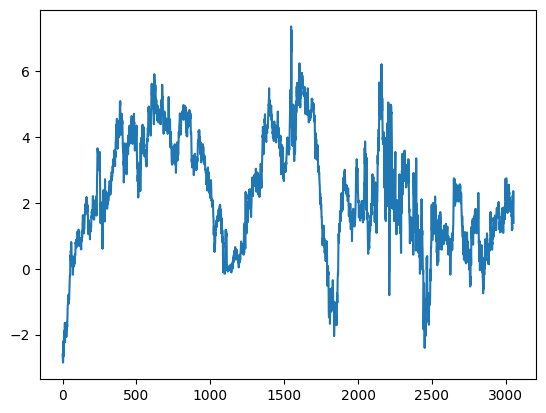

In [190]:
plt.plot(cal.lambdaSeriesFromForwards(tau = 14, tauPrime = 15, deltaTau=1, **calParams))

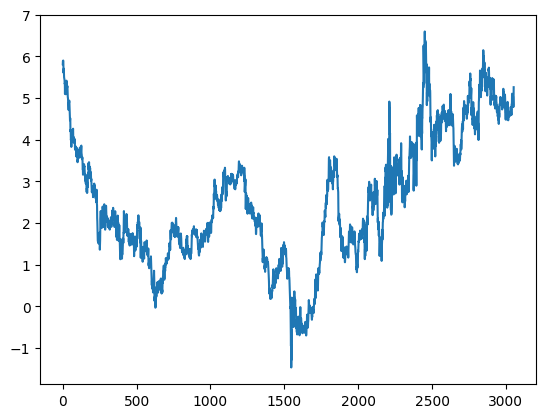

In [201]:
plt.plot(cal.expectedShortRateSeries(tau = 14, tauPrime = 15, deltaTau=1, **calParams))

### 4. Do the residuals mean-revert?

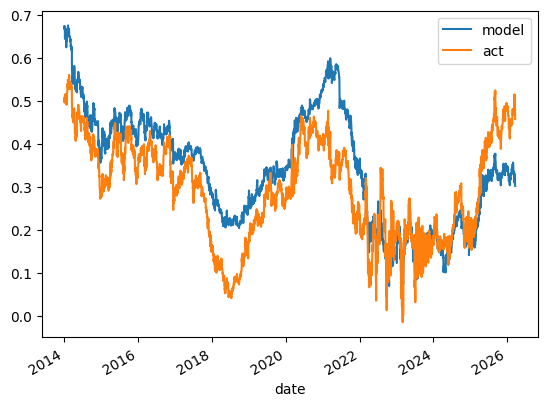

In [38]:
(fittedTs_full_df[20] - fittedTs_full_df[12]).plot(label = 'model')
(termStructurePath[20] - termStructurePath[12]).plot(label = 'act')
plt.legend()

<Axes: xlabel='date'>

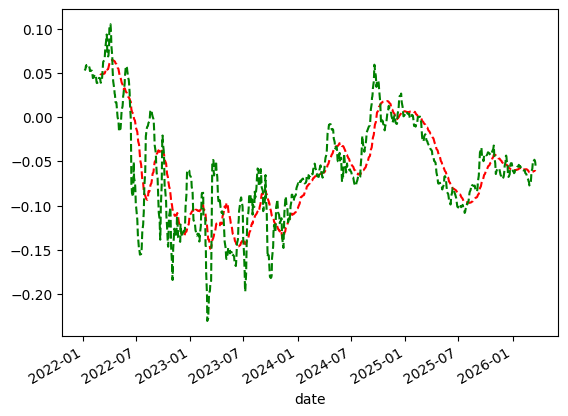

In [31]:
#fittingErrors['2022-01-01':][5].plot()
fittingErrors['2022-01-01':][5].rolling(40).mean().plot(color = 'red', linestyle = '--')
fittingErrors['2022-01-01':][5].rolling(5).mean().plot(color = 'green', linestyle = '--')

<Axes: xlabel='date'>

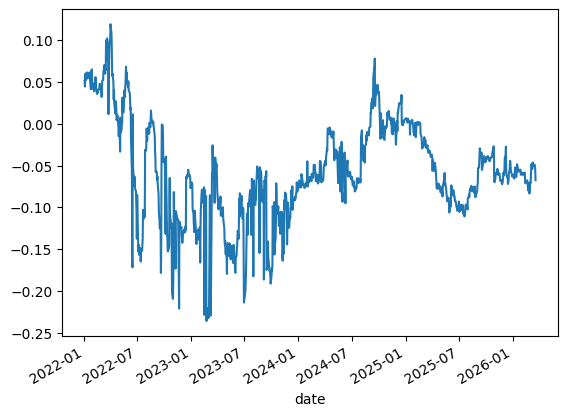

In [26]:
(fittedTs_full_df['2022-01-01':][5] - termStructurePath['2022-01-01':][5]).plot()
#termStructurePath['2022-01-01':][5].plot()

### 5. PCA of residuals (kinda irrelevant, they inherit the same structure as the yield curve)

In [88]:
Sigma = fittingErrors.diff().corr().values
vals, vecs = np.linalg.eigh(Sigma)
idx = np.argsort(vals)[::-1]
vals = vals[idx]
vals = vals/np.sum(vals)
vecs = vecs[:, idx]

loadings = pd.DataFrame(vecs, columns = [f'PC{i}' for i in range(1, len(vals)+1)], index = [f'{i}y' for i in fittingErrors.columns])

/var/folders/6s/ljt_tdhn2332n40p605w9dgr0000gn/T/ipykernel_8408/1497839663.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[i].set_xticklabels(ax[i].get_xticklabels(), rotation=90)
/var/folders/6s/ljt_tdhn2332n40p605w9dgr0000gn/T/ipykernel_8408/1497839663.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[i].set_xticklabels(ax[i].get_xticklabels(), rotation=90)
/var/folders/6s/ljt_tdhn2332n40p605w9dgr0000gn/T/ipykernel_8408/1497839663.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[i].set_xticklabels(ax[i].get_xticklabels(), rotation=90)


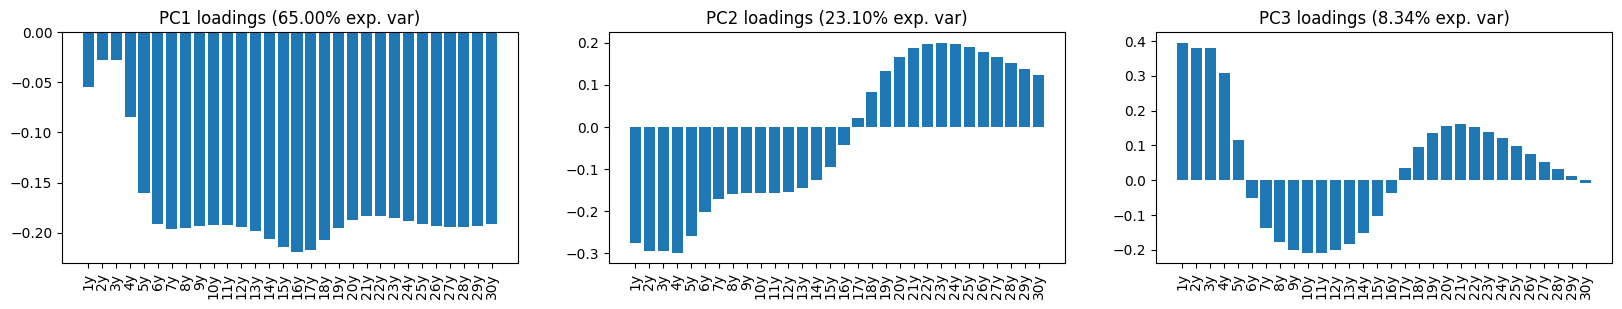

In [89]:
fig, ax = plt.subplots(nrows=1, ncols=3, figsize = (20, 3))
for i in range(0,3):
    ax[i].bar(loadings.index, loadings[f'PC{i+1}'])
    ax[i].set_title(f'PC{i+1} loadings ({vals[i]:.2%} exp. var)')
    ax[i].set_xticklabels(ax[i].get_xticklabels(), rotation=90)

### X. Dump

Tests introducing two premia:
1. the cross-sectional extraction of the two premia fails miserably
2. the time-series extraction is worth taking a look at

In [ ]:
F, D, L = cal.lambdaRegression_twoPremia(tau_0 = 5, tauList = [x for x in cal.maturities if x > 5 and x < 30], 
                                   deltaTau= 1, 
                                   curve = termStructurePath.iloc[-1, 1:].to_list(), **calParams)

contrib_m = D[:, 0] * L[0]
contrib_l = D[:, 1] * L[1]
regr_df = pd.DataFrame([contrib_m, contrib_l, contrib_m + contrib_l,F], index = ['cont.m', 'cont.l', 'fitted', 'actual']).T
regr_df['resid'] = regr_df['actual'] - regr_df['fitted']

In [ ]:
y, X, L = cal.lambdaRegression_twoPremia_ts(tauList=[x for x in cal.maturities if x > 12 and x < 30], 
                                            deltaTau= 1, **calParams)

print(L)

[-0.67397851  9.96042021]


In [ ]:
output = cal.lambdaRegression_twoPremia_ts_exp(tauList=[x for x in cal.maturities if x > 12 and x < 30], 
                                            deltaTau= 1, **calParams)

Lseries = output['lambda_series']

In [ ]:
driftMedium = np.array([
    fittedPricer.amountOfRisk_drift_medium(tau=x, deltaTau=1)
    for x in cal.maturities
], dtype=float)

driftLong = np.array([
    fittedPricer.amountOfRisk_drift_long(tau=x, deltaTau=1)
    for x in cal.maturities
], dtype=float)

convexity = np.array([
    fittedPricer.amountOfRisk_convexity(tau=x, deltaTau=1)
    for x in cal.maturities
], dtype=float)

mediumRp = Lseries[:, 0][:, None] * driftMedium[None, :]
longRp   = Lseries[:, 1][:, None] * driftLong[None, :]
convRp   = convexity[None, :]

rp = mediumRp + longRp + convRp

In [ ]:
mediumRp = L[0] * np.array([fittedPricer.amountOfRisk_drift_medium(tau = x, deltaTau = 1) for x in cal.maturities])
longRp = L[1] * np.array([fittedPricer.amountOfRisk_drift_long(tau = x, deltaTau = 1) for x in cal.maturities])
convexity = np.array([fittedPricer.amountOfRisk_convexity(tau = x, deltaTau=1) for x in cal.maturities])

rp = mediumRp + longRp + convexity

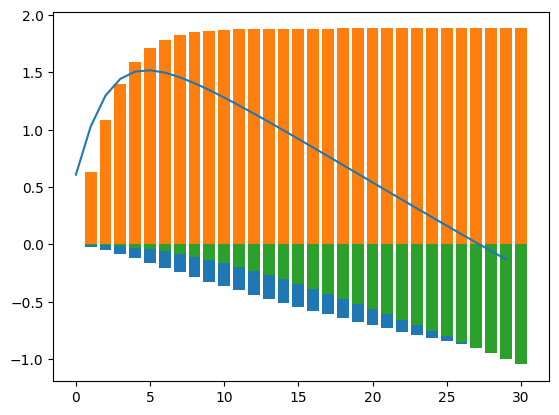

In [ ]:
plt.bar(cal.maturities, mediumRp)
plt.bar(cal.maturities, longRp)
plt.bar(cal.maturities, convexity)
plt.plot(rp)

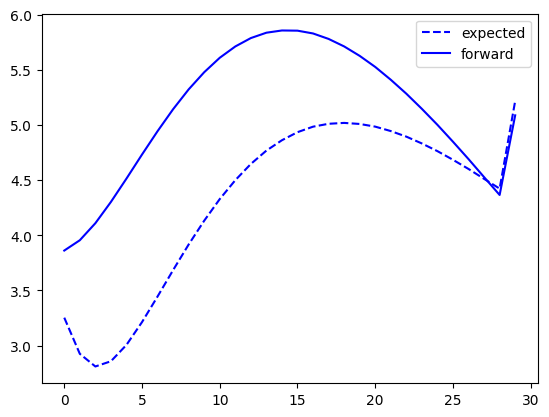

In [ ]:
plt.plot(forwardCurveToday - rp, label = 'expected', color = 'blue', linestyle = '--')
plt.plot(forwardCurveToday, label = 'forward', color = 'blue')
plt.legend()

In [ ]:
series = [
    cal.lambdaRegression_twoPremia(tau_0 = 12, tauList = [x for x in cal.maturities if x > 12], 
                                   deltaTau= 1, 
                                   curve = termStructurePath.iloc[x, 1:].to_list(), **calParams) for x in range(-100, 0)]

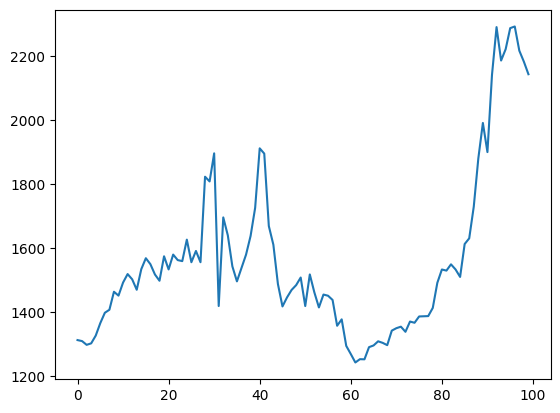

In [ ]:
plt.plot([x[1] for x in series])